# 03 — Modelo econométrico final e Inefficiency Score

**TFM:** Market Value Dynamics and Inefficiency in European Football Transfers  
**Unidad de análisis:** jugador–temporada  
**Target principal:** `log_market_value_eur`  
**Validación:** temporal out-of-sample, entrenando con temporadas anteriores y evaluando en `2024-2025`.

Este notebook consolida el modelo econométrico interpretable del proyecto. Parte del baseline ya validado en el notebook 02 y avanza hacia una especificación final con efectos fijos, feature engineering deportivo y construcción robusta del `Inefficiency Score`.

## 1. Objetivo analítico y decisión de negocio

El objetivo analítico es estimar el valor esperado de mercado de un jugador joven a partir de variables deportivas, demográficas y contextuales. La diferencia entre valor esperado y valor observado permite identificar posibles ineficiencias de mercado.

La decisión de negocio que se mejora es la **priorización de jugadores para scouting y fichaje**, especialmente en perfiles jóvenes de 18 a 23 años en ligas europeas donde pueden existir descuentos estructurales o menor eficiencia de mercado.

El modelo no sustituye al scouting experto. Funciona como una primera capa cuantitativa para reducir el universo de análisis y ordenar oportunidades potenciales.

## 2. Especificación econométrica

La especificación principal es:

\[
\log(MV_{i,t}) = \beta X_{i,t} + \gamma_{league} + \delta_{season} + \theta_{position} + \varepsilon_{i,t}
\]

Donde:

- \(MV_{i,t}\) es el valor de mercado del jugador \(i\) en la temporada \(t\).
- \(X_{i,t}\) incluye edad, minutos, producción ofensiva y variables deportivas avanzadas disponibles.
- \(\gamma_{league}\) controla diferencias estructurales entre ligas.
- \(\delta_{season}\) controla shocks de temporada.
- \(\theta_{position}\) controla diferencias por rol posicional.

Se usan errores estándar robustos HC3 para mitigar heterocedasticidad e influencia de observaciones extremas.

In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TEST_SEASON = "2024-2025"
TARGET = "log_market_value_eur"
RANDOM_STATE = 42

In [2]:
# ============================================================
# 2. Rutas del proyecto
# ============================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: c:\Users\manue\Projects\market-value-football-tfm
DATA_PATH: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
OUTPUT_DIR: c:\Users\manue\Projects\market-value-football-tfm\data\outputs


## 3. Carga y validación del dataset modelizable

Se carga el dataset final `player_season_modeling.parquet`, construido tras el matching FBref–Transfermarkt y los filtros de edad, minutos, posición, valor de mercado y calidad mínima de emparejamiento.

In [3]:
# ============================================================
# 3. Carga del dataset
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe {DATA_PATH}. Ejecuta antes src.data.build_modeling_dataset."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Players: {df['player_name_fbref'].nunique() if 'player_name_fbref' in df.columns else 'n/a'}")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")
df.head()

Dataset cargado
Rows: 3,297
Columns: 54
Players: 1847
Seasons: 2019-2020 - 2024-2025


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
1,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
2,Shurandy Sambo,Sparta Rotterdam,Eredivisie,2022-2023,2022,DF,DEF,20.0000,30,28,2307,25.6000,2,1,3,2,0,0,4,2,0.0800,0.0400,0.1200,0.0800,0.1200,shurandy sambo,"412,937.0000",Shurandy Sambo,"2,022.0000",2022-11-11,"700,000.0000",13.4588,"500,000.0000","3,000,000.0000",3.2857,1.4553,21.2293,2001-08-19 00:00:00,Curacao,Defender,Right-Back,right,174.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2293,100.0000,True,2022,21.2293
3,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2023-2024,2023,MF,MID,21.0000,24,24,2106,23.4000,5,2,7,3,2,2,2,0,0.2100,0.0900,0.3000,0.1300,0.2100,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,023.0000",2023-12-15,"4,500,000.0000",15.3196,"4,500,000.0000","4,500,000.0000",0.0000,0.0000,22.3655,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3655,100.0000,True,2023,22.3655
4,Jakob Breum,Go Ahead Eagles,Eredivisie,2024-2025,2024,MF,MID,20.0000,26,23,2059,22.9000,10,5,15,10,0,0,4,0,0.4400,0.2200,0.6600,0.4400,0.6600,jakob breum,"657,957.0000",Jakob Breum,"2,024.0000",2024-10-14,"1,500,000.0000",14.2210,"1,000,000.0000","2,300,000.0000",0.5333,0.4274,20.9090,2003-11-17 00:00:00,Denmark,Midfield,Attacking Midfield,right,178.0000,Go Ahead Eagles,"1,435.0000",NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.9090,100.0000,True,2024,20.9090


In [4]:
# ============================================================
# 4. Normalización de columnas auxiliares
# ============================================================

model_df = df.copy()

# Nombre de jugador para rankings
if "player_name" not in model_df.columns:
    if "player_name_fbref" in model_df.columns:
        model_df["player_name"] = model_df["player_name_fbref"]
    elif "player_name_tm" in model_df.columns:
        model_df["player_name"] = model_df["player_name_tm"]

# Edad consolidada
if "age" not in model_df.columns:
    if "age_tm" in model_df.columns:
        model_df["age"] = model_df["age_tm"]
    elif "age_fbref" in model_df.columns:
        model_df["age"] = model_df["age_fbref"]

# Log de minutos
if "minutes_played" not in model_df.columns:
    raise KeyError("Falta minutes_played, variable mínima para el modelo.")

model_df["log_minutes_played"] = np.log1p(model_df["minutes_played"])

required = [TARGET, "market_value_eur", "season", "league", "position_group", "age", "log_minutes_played"]
missing = [c for c in required if c not in model_df.columns]
if missing:
    raise KeyError(f"Faltan columnas obligatorias: {missing}")

print("Columnas mínimas validadas correctamente")

Columnas mínimas validadas correctamente


## 4. Feature engineering deportivo

Se incorporan variables deportivas disponibles en el dataset. Cuando existen métricas suficientes, se construyen índices normalizados por `position_group` y `league` para mejorar comparabilidad entre roles y contextos competitivos.

La lógica es conservadora: no se fuerza ninguna variable inexistente. El notebook detecta columnas disponibles y ajusta la especificación final automáticamente.

In [5]:
# ============================================================
# 5. Feature engineering robusto según columnas disponibles
# ============================================================

PERFORMANCE_CANDIDATES = [
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
]

available_perf = [c for c in PERFORMANCE_CANDIDATES if c in model_df.columns]
print("Variables deportivas disponibles:", available_perf)

for col in available_perf:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


def safe_zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

# Z-scores por posición y liga para controlar comparabilidad contextual
for col in available_perf:
    z_col = f"z_{col}"
    model_df[z_col] = (
        model_df
        .groupby(["position_group", "league"], dropna=False)[col]
        .transform(safe_zscore)
    )

# Índices interpretables, solo si existen los componentes necesarios
if {"z_goals_per90", "z_shots_per90"}.issubset(model_df.columns):
    model_df["finishing_index"] = model_df[["z_goals_per90", "z_shots_per90"]].mean(axis=1)

if {"z_assists_per90", "z_progressive_passes_per90"}.issubset(model_df.columns):
    model_df["playmaking_index"] = model_df[["z_assists_per90", "z_progressive_passes_per90"]].mean(axis=1)

if {"z_progressive_passes_per90", "z_progressive_carries_per90"}.issubset(model_df.columns):
    model_df["progression_index"] = model_df[["z_progressive_passes_per90", "z_progressive_carries_per90"]].mean(axis=1)

if {"z_tackles_per90", "z_interceptions_per90"}.issubset(model_df.columns):
    model_df["defensive_index"] = model_df[["z_tackles_per90", "z_interceptions_per90"]].mean(axis=1)

created_indexes = [c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"] if c in model_df.columns]
print("Índices creados:", created_indexes)

Variables deportivas disponibles: ['goals_per90', 'assists_per90']
Índices creados: []


## 5. Split temporal train/test

La evaluación se realiza con validación temporal. El modelo se entrena con temporadas anteriores y se evalúa en `2024-2025`, simulando el uso real del sistema para estimar jugadores en una temporada futura no vista.

In [6]:
# ============================================================
# 6. Muestra econométrica y split temporal
# ============================================================

BASE_NUMERIC_FEATURES = [
    "age",
    "log_minutes_played",
]

# Mantener producción ofensiva directa si está disponible
for c in ["goals_per90", "assists_per90"]:
    if c in model_df.columns:
        BASE_NUMERIC_FEATURES.append(c)

ADVANCED_FEATURES = [
    c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"]
    if c in model_df.columns
]

FINAL_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + ADVANCED_FEATURES
CATEGORICAL_FEATURES = ["league", "season", "position_group"]

needed = [TARGET, "market_value_eur"] + FINAL_NUMERIC_FEATURES + CATEGORICAL_FEATURES
model_df = model_df.dropna(subset=needed).copy()

train = model_df[model_df["season"] != TEST_SEASON].copy()
test = model_df[model_df["season"] == TEST_SEASON].copy()

if train.empty or test.empty:
    raise ValueError("El split temporal ha generado train o test vacío. Revisa TEST_SEASON.")

print("Features finales:", FINAL_NUMERIC_FEATURES)
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print("Train seasons:", sorted(train["season"].unique()))
print("Test seasons:", sorted(test["season"].unique()))

Features finales: ['age', 'log_minutes_played', 'goals_per90', 'assists_per90']
Train rows: 2,745
Test rows: 552
Train seasons: ['2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Test seasons: ['2024-2025']


In [7]:
# Descriptivo de la muestra final
summary_sample = pd.DataFrame({
    "rows": [len(model_df)],
    "players": [model_df["player_name"].nunique() if "player_name" in model_df.columns else np.nan],
    "train_rows": [len(train)],
    "test_rows": [len(test)],
    "n_leagues": [model_df["league"].nunique()],
    "n_seasons": [model_df["season"].nunique()],
})
summary_sample

,rows,players,train_rows,test_rows,n_leagues,n_seasons
0,3297,1847,2745,552,7,6


## 6. Funciones de modelización y evaluación

Se construyen matrices de diseño consistentes entre train y test. Las dummies del test se alinean con las columnas del train para evitar errores cuando alguna categoría no aparece en una partición.

In [8]:
# ============================================================
# 7. Funciones auxiliares
# ============================================================

def build_X(data: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    X = data[numeric_features + categorical_features].copy()
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)
    X = sm.add_constant(X, has_constant="add")
    return X.astype(float)


def align_X(X_new: pd.DataFrame, X_train: pd.DataFrame) -> pd.DataFrame:
    return X_new.reindex(columns=X_train.columns, fill_value=0.0).astype(float)


def fit_ols_hc3(train_df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]):
    X_train = build_X(train_df, numeric_features, categorical_features)
    y_train = train_df[TARGET].astype(float)
    fitted = sm.OLS(y_train, X_train).fit(cov_type="HC3")
    return fitted, X_train


def predict_with_design(fitted, data: pd.DataFrame, X_train: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> np.ndarray:
    X_new = build_X(data, numeric_features, categorical_features)
    X_new = align_X(X_new, X_train)
    return fitted.predict(X_new)


def regression_metrics(y_true, y_pred, model_name: str, split: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": model_name,
        "split": split,
        "n": len(y_true),
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

## 7. Modelos estimados

Se comparan cuatro niveles:

- **M0:** media del target en train.
- **M1:** OLS parsimonioso sin efectos fijos.
- **M2:** OLS base con efectos fijos de liga, temporada y posición.
- **M3:** OLS final con efectos fijos y features deportivas avanzadas disponibles.

El modelo candidato final será M3 si mejora o mantiene rendimiento con interpretación económica coherente. Si las variables avanzadas no existen en el dataset, M3 coincide parcialmente con M2.

In [9]:
# ============================================================
# 8. Estimación de modelos
# ============================================================

models = {}
metrics = []

# M0: media de train
m0_pred_train = np.repeat(train[TARGET].mean(), len(train))
m0_pred_test = np.repeat(train[TARGET].mean(), len(test))
metrics.append(regression_metrics(train[TARGET], m0_pred_train, "M0_mean_train", "train"))
metrics.append(regression_metrics(test[TARGET], m0_pred_test, "M0_mean_train", "test"))

# M1: base sin FE
m1_features = BASE_NUMERIC_FEATURES
m1, X1_train = fit_ols_hc3(train, m1_features, [])
models["M1_base_no_FE"] = (m1, X1_train, m1_features, [])

# M2: base + FE
m2, X2_train = fit_ols_hc3(train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M2_base_FE"] = (m2, X2_train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# M3: final + advanced features + FE
m3, X3_train = fit_ols_hc3(train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M3_final_FE_advanced"] = (m3, X3_train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

for name, (fitted, Xtr, num_feats, cat_feats) in models.items():
    pred_train = predict_with_design(fitted, train, Xtr, num_feats, cat_feats)
    pred_test = predict_with_design(fitted, test, Xtr, num_feats, cat_feats)
    metrics.append(regression_metrics(train[TARGET], pred_train, name, "train"))
    metrics.append(regression_metrics(test[TARGET], pred_test, name, "test"))

metrics_df = pd.DataFrame(metrics).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "03_econometric_model_metrics.csv", index=False)
metrics_df

,model,split,n,MAE_log,RMSE_log,R2
5,M2_base_FE,test,552,0.7907,0.9823,0.4439
7,M3_final_FE_advanced,test,552,0.7907,0.9823,0.4439
3,M1_base_no_FE,test,552,1.0036,1.2165,0.1472
1,M0_mean_train,test,552,1.0899,1.3212,-0.0059
4,M2_base_FE,train,2745,0.8191,1.0082,0.4093
6,M3_final_FE_advanced,train,2745,0.8191,1.0082,0.4093
2,M1_base_no_FE,train,2745,1.0146,1.2186,0.1369
0,M0_mean_train,train,2745,1.0960,1.3117,0.0000


## 8. Modelo econométrico final

Se toma `M3_final_FE_advanced` como especificación principal porque mantiene la estructura interpretable del baseline y permite incorporar señales deportivas más ricas sin abandonar el marco econométrico.

In [10]:
# ============================================================
# 9. Resumen del modelo final
# ============================================================

final_model_name = "M3_final_FE_advanced"
final_model, X_final_train, final_numeric_features, final_categorical_features = models[final_model_name]

print(final_model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       0.409
Model:                              OLS   Adj. R-squared:                  0.406
Method:                   Least Squares   F-statistic:                     130.3
Date:                  Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                          22:16:52   Log-Likelihood:                -3917.4
No. Observations:                  2745   AIC:                             7871.
Df Residuals:                      2727   BIC:                             7977.
Df Model:                            17                                         
Covariance Type:                    HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const     

In [11]:
# Tabla de coeficientes
coef_table = pd.DataFrame({
    "term": final_model.params.index,
    "coef": final_model.params.values,
    "std_err_HC3": final_model.bse.values,
    "t": final_model.tvalues.values,
    "p_value": final_model.pvalues.values,
})
coef_table["significant_5pct"] = coef_table["p_value"] < 0.05
coef_table.to_csv(OUTPUT_DIR / "03_econometric_model_coefficients.csv", index=False)
coef_table.sort_values("p_value").head(30)

,term,coef,std_err_HC3,t,p_value,significant_5pct
0,const,10.7631,0.4013,26.8233,0.0000,True
5,league_Eredivisie,-1.4466,0.0718,-20.1416,0.0000,True
2,log_minutes_played,0.5481,0.0330,16.6126,0.0000,True
7,league_Liga Portugal,-1.1222,0.0827,-13.5746,0.0000,True
3,goals_per90,1.4129,0.1298,10.8878,0.0000,True
9,league_Premier League,0.7110,0.0705,10.0843,0.0000,True
4,assists_per90,1.7832,0.1833,9.7258,0.0000,True
8,league_Ligue 1,-0.3363,0.0708,-4.7470,0.0000,True
11,season_2020-2021,-0.1620,0.0636,-2.5470,0.0109,True
14,season_2023-2024,-0.1488,0.0606,-2.4571,0.0140,True


In [12]:
# Coeficientes principales en variables deportivas/demográficas
main_terms = ["age", "log_minutes_played", "goals_per90", "assists_per90"] + ADVANCED_FEATURES
coef_table[coef_table["term"].isin(main_terms)].sort_values("term")

,term,coef,std_err_HC3,t,p_value,significant_5pct
1,age,0.0397,0.0170,2.3334,0.0196,True
4,assists_per90,1.7832,0.1833,9.7258,0.0000,True
3,goals_per90,1.4129,0.1298,10.8878,0.0000,True
2,log_minutes_played,0.5481,0.0330,16.6126,0.0000,True


## 9. Diagnóstico de multicolinealidad

El VIF se calcula sobre variables continuas centradas/escaladas y dummies de efectos fijos. Esto evita que la escala de edad o minutos infle artificialmente el diagnóstico.

In [13]:
# ============================================================
# 10. VIF con continuas estandarizadas
# ============================================================

vif_df_source = train[final_numeric_features + final_categorical_features].copy()

for col in final_numeric_features:
    mean = vif_df_source[col].mean()
    std = vif_df_source[col].std(ddof=0)
    vif_df_source[col] = 0.0 if std == 0 or pd.isna(std) else (vif_df_source[col] - mean) / std

X_vif = pd.get_dummies(vif_df_source, columns=final_categorical_features, drop_first=True, dtype=float)
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    try:
        vif_rows.append({"variable": col, "VIF": variance_inflation_factor(X_vif.values, i)})
    except Exception:
        vif_rows.append({"variable": col, "VIF": np.nan})

vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif_table.to_csv(OUTPUT_DIR / "03_vif_table.csv", index=False)
vif_table.head(25)

,variable,VIF
14,position_group_DEF,3.7964
16,position_group_MID,3.2687
7,league_Ligue 1,2.0207
4,league_Eredivisie,1.9213
9,league_Serie A,1.8542
8,league_Premier League,1.8058
13,season_2023-2024,1.6534
5,league_LaLiga,1.6532
11,season_2021-2022,1.6251
10,season_2020-2021,1.6198


## 10. Predicción out-of-sample y residuos

Las predicciones se generan sobre test (`2024-2025`) y se transforman de vuelta a euros para producir gaps interpretables por negocio.

In [14]:
# ============================================================
# 11. Predicciones train/test y residuos
# ============================================================

def add_predictions(data: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = data.copy()
    out["split"] = split_name
    out["predicted_log_market_value"] = predict_with_design(
        final_model,
        out,
        X_final_train,
        final_numeric_features,
        final_categorical_features,
    )
    out["predicted_market_value_eur"] = np.exp(out["predicted_log_market_value"])
    out["residual_log_observed_minus_predicted"] = out[TARGET] - out["predicted_log_market_value"]
    out["inefficiency_score"] = out["predicted_log_market_value"] - out[TARGET]
    out["market_value_gap_eur"] = out["predicted_market_value_eur"] - out["market_value_eur"]
    out["market_value_gap_pct"] = out["market_value_gap_eur"] / out["market_value_eur"]
    return out

train_scored = add_predictions(train, "train")
test_scored = add_predictions(test, "test")
scored = pd.concat([train_scored, test_scored], ignore_index=True)

# Score estandarizado usando distribución de train para evitar leakage
score_mean = train_scored["inefficiency_score"].mean()
score_std = train_scored["inefficiency_score"].std(ddof=0)
scored["inefficiency_score_z"] = (scored["inefficiency_score"] - score_mean) / score_std if score_std > 0 else 0.0

# Confidence Score preliminar basado en matching_confidence si existe
if "matching_confidence" in scored.columns:
    scored["confidence_score"] = pd.to_numeric(scored["matching_confidence"], errors="coerce").fillna(0.5)
else:
    scored["confidence_score"] = 1.0

scored["opportunity_score"] = scored["inefficiency_score_z"] * scored["confidence_score"]

scored[["split", TARGET, "predicted_log_market_value", "inefficiency_score", "market_value_gap_eur", "opportunity_score"]].head()

,split,log_market_value_eur,predicted_log_market_value,inefficiency_score,market_value_gap_eur,opportunity_score
0,train,13.9978,14.6888,0.6910,"1,194,734.5520",0.6853
1,train,15.7614,16.5572,0.7958,"8,513,122.1965",0.7893
2,train,13.4588,14.5067,1.0478,"1,296,030.2594",1.0393
3,train,15.3196,14.7081,-0.6115,"-2,058,618.7632",-0.6065
4,train,15.8950,16.4241,0.5291,"5,579,615.0493",0.5248


In [15]:
# Métricas finales del modelo seleccionado
final_metrics = []
for split_name, d in [("train", train_scored), ("test", test_scored)]:
    final_metrics.append(regression_metrics(d[TARGET], d["predicted_log_market_value"], final_model_name, split_name))
final_metrics_df = pd.DataFrame(final_metrics)
final_metrics_df

,model,split,n,MAE_log,RMSE_log,R2
0,M3_final_FE_advanced,train,2745,0.8191,1.0082,0.4093
1,M3_final_FE_advanced,test,552,0.7907,0.9823,0.4439


In [16]:
# Exportación de predicciones
scored.to_parquet(OUTPUT_DIR / "03_econometric_scored_player_seasons.parquet", index=False)
test_scored.to_parquet(OUTPUT_DIR / "03_econometric_test_predictions.parquet", index=False)

print(f"Predicciones exportadas a {OUTPUT_DIR}")

Predicciones exportadas a c:\Users\manue\Projects\market-value-football-tfm\data\outputs


## 11. Visualizaciones de diagnóstico

Se revisan tres gráficos básicos:

1. Observado vs predicho en test.
2. Distribución de residuos en test.
3. Residuos frente a predicción en test.

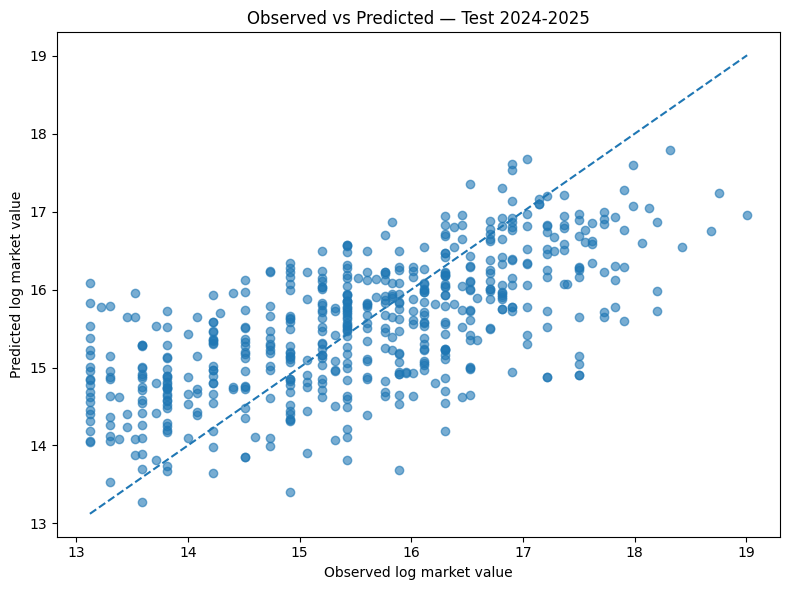

In [17]:
# Observado vs predicho en test
plt.figure(figsize=(8, 6))
plt.scatter(test_scored[TARGET], test_scored["predicted_log_market_value"], alpha=0.6)
min_val = min(test_scored[TARGET].min(), test_scored["predicted_log_market_value"].min())
max_val = max(test_scored[TARGET].max(), test_scored["predicted_log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Observed log market value")
plt.ylabel("Predicted log market value")
plt.title("Observed vs Predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_observed_vs_predicted_test.png", dpi=150)
plt.show()

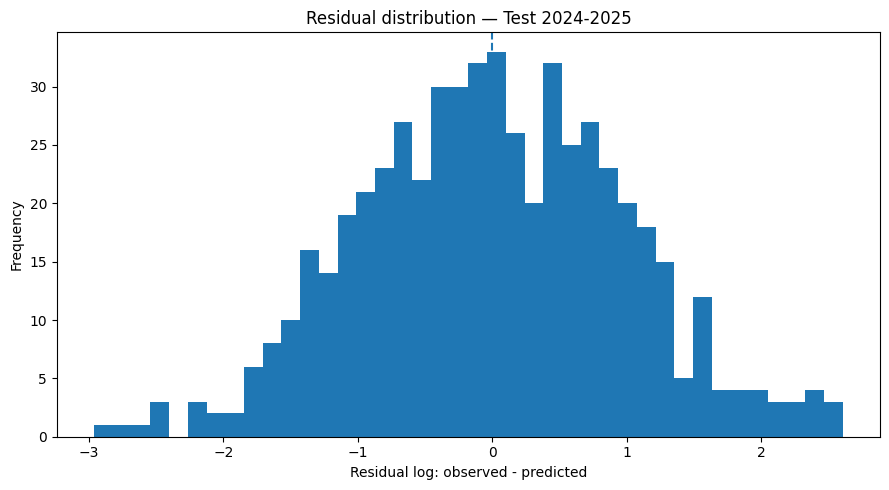

In [18]:
# Distribución de residuos en test
plt.figure(figsize=(9, 5))
plt.hist(test_scored["residual_log_observed_minus_predicted"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residual_distribution_test.png", dpi=150)
plt.show()

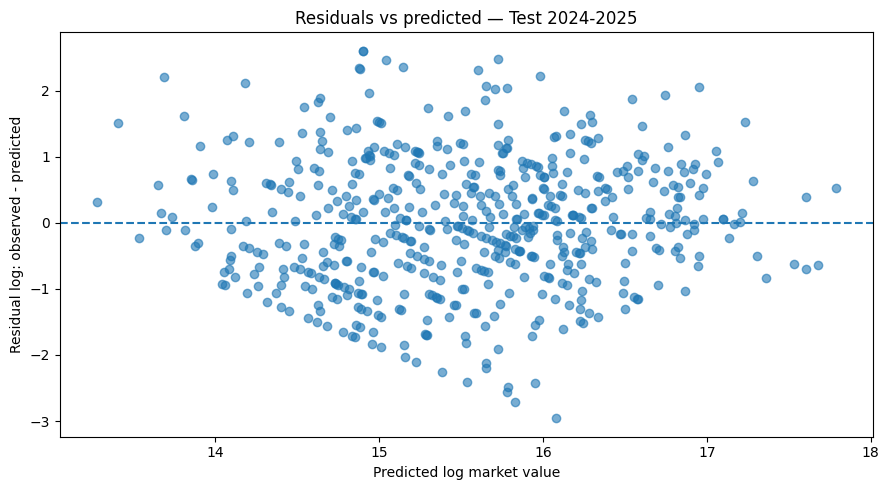

In [19]:
# Residuos vs predicción en test
plt.figure(figsize=(9, 5))
plt.scatter(test_scored["predicted_log_market_value"], test_scored["residual_log_observed_minus_predicted"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log market value")
plt.ylabel("Residual log: observed - predicted")
plt.title("Residuals vs predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals_vs_predicted_test.png", dpi=150)
plt.show()

## 12. Inefficiency Score final

Se fija la convención definitiva:

\[
\text{Inefficiency Score}_{i,t} = \widehat{\log(MV)}_{i,t} - \log(MV)_{i,t}
\]

Interpretación:

- `inefficiency_score > 0`: el modelo estima un valor superior al observado → posible infravaloración.
- `inefficiency_score < 0`: el valor observado supera el valor esperado → posible sobrevaloración.

En euros:

\[
\text{market value gap}_{i,t} = \widehat{MV}_{i,t} - MV_{i,t}
\]

Esta convención se utiliza en todos los rankings del proyecto.

In [20]:
# ============================================================
# 12. Rankings sobre test out-of-sample
# ============================================================

test_scored_final = scored[scored["split"] == "test"].copy()

ranking_cols = [c for c in [
    "player_id_tm", "player_id", "player_name", "club", "current_club_name_tm",
    "league", "season", "position_group", "age", "minutes_played",
    "market_value_eur", "predicted_market_value_eur",
    "market_value_gap_eur", "market_value_gap_pct",
    "log_market_value_eur", "predicted_log_market_value",
    "inefficiency_score", "inefficiency_score_z",
    "confidence_score", "opportunity_score",
    "matching_method", "matching_confidence", "age_diff", "club_score",
] if c in test_scored_final.columns]

undervalued_ranking = (
    test_scored_final
    .query("inefficiency_score > 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ranking = (
    test_scored_final
    .query("inefficiency_score < 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ranking.to_csv(OUTPUT_DIR / "03_undervalued_ranking.csv", index=False)
overvalued_ranking.to_csv(OUTPUT_DIR / "03_overvalued_ranking.csv", index=False)

display(undervalued_ranking.head(20))

,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
2747,"512,352.0000",Lasse Rosenboom,Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","9,640,147.6637","9,140,147.6637",18.2803,13.1224,16.0814,2.9591,2.9350,1.0000,2.9350,exact_age_club_validated,1.0000,0.9185,100.0000
3185,"948,273.0000",Mario Martín,Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","7,487,716.8065","6,987,716.8065",13.9754,13.1224,15.8288,2.7064,2.6844,0.8500,2.2818,exact_age_validated,0.8500,0.6023,20.8333
3054,"610,608.0000",Dominik Javorček,Holstein Kiel,"SK Slavia Praha, a.s.",Bundesliga,2024-2025,DEF,22.1328,386,"550,000.0000","7,134,293.5050","6,584,293.5050",11.9714,13.2177,15.7804,2.5628,2.5419,0.8500,2.1606,exact_age_validated,0.8500,1.1328,31.2500
2999,"1,390,649.0000",Yan Diomandé,Leganés,RasenBallsport Leipzig,LaLiga,2024-2025,MID,18.4723,545,"600,000.0000","7,176,285.5845","6,576,285.5845",10.9605,13.3047,15.7863,2.4816,2.4614,0.8500,2.0922,exact_age_validated,0.8500,1.4723,41.3793
2880,"927,353.0000",Johan Manzambi,Freiburg,Sport-Club Freiburg,Bundesliga,2024-2025,MID,18.9870,335,"750,000.0000","8,454,904.7159","7,704,904.7159",10.2732,13.5278,15.9503,2.4224,2.4027,0.8500,2.0423,exact_age_validated,0.8500,0.9870,59.2593
3042,"807,688.0000",Yassin Belkhdim,Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","5,583,610.4478","5,083,610.4478",10.1672,13.1224,15.5353,2.4130,2.3934,0.8500,2.0344,exact_age_validated,0.8500,0.6448,32.4324
2966,"1,061,336.0000",Pau Navarro,Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,789,324.9691","4,289,324.9691",8.5786,13.1224,15.3819,2.2595,2.2412,0.8500,1.9050,exact_age_validated,0.8500,0.6496,48.7805
3214,"1,190,411.0000",Jesus Rodríguez,Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","6,259,922.6766","5,559,922.6766",7.9427,13.4588,15.6497,2.1908,2.1730,0.8500,1.8471,exact_age_validated,0.8500,0.8966,19.0476
2883,"917,375.0000",Antoine Hainaut,Parma,Parma Calcio 1913,Serie A,2024-2025,DEF,22.6639,1206,"750,000.0000","6,281,850.8195","5,531,850.8195",7.3758,13.5278,15.6532,2.1253,2.1081,0.8500,1.7919,exact_age_validated,0.8500,0.6639,58.8235
3050,"743,496.0000",Kévin Danois,Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","4,099,325.2251","3,599,325.2251",7.1987,13.1224,15.2263,2.1040,2.0869,0.8500,1.7738,exact_age_validated,0.8500,0.2765,31.8182


In [21]:
print("Top overvalued players — test")
display(overvalued_ranking.head(20))

Top overvalued players — test


,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
2783,"810,092.0000",Warren Zaïre-Emery,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,18.7598,2050,"60,000,000.0000","5,974,618.9352","-54,025,381.0648",-0.9004,17.9099,15.6030,-2.3068,-2.2881,1.0000,-2.2881,exact_age_club_validated,1.0000,0.7598,73.0769
2969,"650,568.0000",António Silva,Benfica,Sport Lisboa e Benfica,Liga Portugal,2024-2025,DEF,20.9418,2037,"40,000,000.0000","2,959,009.5647","-37,040,990.4353",-0.9260,17.5044,14.9004,-2.6040,-2.5829,0.8500,-2.1954,exact_age_validated,0.8500,0.9418,48.2759
2870,"974,982.0000",Ousmane Diomande,Sporting CP,Sporting Clube de Portugal,Liga Portugal,2024-2025,DEF,21.0431,2521,"40,000,000.0000","2,967,060.6726","-37,032,939.3274",-0.9258,17.5044,14.9031,-2.6013,-2.5802,0.8500,-2.1931,exact_age_validated,0.8500,1.0431,59.4595
2868,"646,740.0000",Gavi,Barcelona,Futbol Club Barcelona,LaLiga,2024-2025,MID,20.3943,1085,"80,000,000.0000","6,755,332.4395","-73,244,667.5605",-0.9156,18.1975,15.7258,-2.4717,-2.4516,0.8500,-2.0839,exact_age_validated,0.8500,1.3943,60.0000
3252,"565,424.0000",Johan Bakayoko,PSV,RasenBallsport Leipzig,Eredivisie,2024-2025,MID,21.6619,1579,"40,000,000.0000","3,407,803.5703","-36,592,196.4297",-0.9148,17.5044,15.0416,-2.4628,-2.4428,0.8500,-2.0764,exact_age_validated,0.8500,0.6619,16.0000
2765,"792,380.0000",Aleksandar Pavlovic,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,20.4353,1451,"50,000,000.0000","6,264,048.4167","-43,735,951.5833",-0.8747,17.7275,15.6503,-2.0772,-2.0603,1.0000,-2.0603,exact_age_club_validated,1.0000,0.4353,80.0000
2787,"616,341.0000",Nuno Mendes,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,22.4778,1676,"55,000,000.0000","7,126,870.0359","-47,873,129.9641",-0.8704,17.8228,15.7794,-2.0435,-2.0269,1.0000,-2.0269,exact_age_club_validated,1.0000,0.4778,73.0769
3101,"971,570.0000",Endrick,Real Madrid,Olympique Lyonnais,LaLiga,2024-2025,ATT,18.4367,363,"40,000,000.0000","3,785,199.9815","-36,214,800.0185",-0.9054,17.5044,15.1466,-2.3578,-2.3386,0.8500,-1.9878,exact_age_validated,0.8500,0.4367,27.5862
3251,"904,802.0000",Jorrel Hato,Ajax,Chelsea Football Club,Eredivisie,2024-2025,DEF,18.7817,2588,"30,000,000.0000","2,892,533.8479","-27,107,466.1521",-0.9036,17.2167,14.8776,-2.3391,-2.3201,0.8500,-1.9721,exact_age_validated,0.8500,0.7817,16.0000
3289,"473,169.0000",Brian Brobbey,Ajax,Sunderland Association Football Club,Eredivisie,2024-2025,ATT,22.8747,1555,"30,000,000.0000","2,905,332.6492","-27,094,667.3508",-0.9032,17.2167,14.8821,-2.3346,-2.3157,0.8500,-1.9683,exact_age_validated,0.8500,0.8747,10.0000


## 13. Análisis agregado del score

Se analiza si el score presenta sesgos sistemáticos por liga o posición. Este bloque es clave para evitar que el ranking final sea solo un ranking de ligas o roles, en lugar de detectar jugadores concretos.

In [22]:
# Asegurar que el subset de test incluye todas las columnas de scoring
test_scored_final = scored[scored["split"] == "test"].copy()

# Inefficiency por liga en test
league_score = (
    test_scored_final
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score", "size"),
        mean_inefficiency=("inefficiency_score", "mean"),
        median_inefficiency=("inefficiency_score", "median"),
        mean_gap_eur=("market_value_gap_eur", "mean"),
        median_gap_eur=("market_value_gap_eur", "median"),
        mean_gap_pct=("market_value_gap_pct", "mean"),
        mean_confidence=("confidence_score", "mean"),
        mean_opportunity=("opportunity_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency", ascending=False)
)

display(league_score)

league_score.to_csv(
    OUTPUT_DIR / "03_inefficiency_by_league_test.csv",
    index=False
)

,league,n,mean_inefficiency,median_inefficiency,mean_gap_eur,median_gap_eur,mean_gap_pct,mean_confidence,mean_opportunity
2,LaLiga,72,0.2361,0.2937,"-6,583,658.3141","1,904,487.4660",1.2499,0.8604,0.2022
6,Serie A,77,0.0759,0.0930,"-1,552,471.9459","456,101.1194",0.5603,0.8539,0.0646
3,Liga Portugal,60,0.0279,0.2855,"-2,310,920.6464","509,078.6484",0.6142,0.8525,0.0238
0,Bundesliga,77,-0.0075,-0.0829,"-6,764,307.7696","-960,764.0463",0.7812,0.8792,-0.0052
1,Eredivisie,93,-0.0240,0.0304,"-1,940,303.3739","97,066.8094",0.4769,0.8629,-0.0103
4,Ligue 1,99,-0.0376,-0.0527,"-4,281,280.3701","-410,671.9808",0.6076,0.8682,-0.0432
5,Premier League,74,-0.2435,-0.2215,"-7,973,511.4326","-4,978,629.6600",0.0205,0.8723,-0.2151


In [23]:
# Re-crear subsets después de calcular todos los scores
train_scored = scored[scored["split"] == "train"].copy()
test_scored = scored[scored["split"] == "test"].copy()

required_scoring_cols = [
    "inefficiency_score",
    "inefficiency_score_z",
    "confidence_score",
    "opportunity_score",
]

missing_cols = [c for c in required_scoring_cols if c not in test_scored.columns]

if missing_cols:
    raise KeyError(f"Missing scoring columns in test_scored: {missing_cols}")

print("Scoring subsets actualizados correctamente")
print(f"Train scored: {train_scored.shape}")
print(f"Test scored: {test_scored.shape}")

Scoring subsets actualizados correctamente
Train scored: (2745, 68)
Test scored: (552, 68)


## 14. Robustness check con matching estricto

Se replica la estimación sobre una submuestra de mayor confianza cuando existen variables de matching. El objetivo no es sustituir el modelo principal, sino comprobar si los resultados son razonablemente estables al aumentar la precisión del emparejamiento.

In [24]:
# ============================================================
# 13. Robustness check: matching estricto
# ============================================================

strict_df = model_df.copy()

if "matching_confidence" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["matching_confidence"], errors="coerce") >= 0.99]

if "age_diff" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["age_diff"], errors="coerce") <= 1.0]

if "matching_method" in strict_df.columns:
    strict_df = strict_df[strict_df["matching_method"].isin([
        "exact_age_validated",
        "exact_age_club_validated",
        "fuzzy_age_club_validated",
    ])]

strict_train = strict_df[strict_df["season"] != TEST_SEASON].copy()
strict_test = strict_df[strict_df["season"] == TEST_SEASON].copy()

print(f"Strict rows: {len(strict_df):,}")
print(f"Strict train rows: {len(strict_train):,}")
print(f"Strict test rows: {len(strict_test):,}")

if len(strict_train) >= 50 and len(strict_test) >= 20:
    strict_model, X_strict_train = fit_ols_hc3(strict_train, final_numeric_features, final_categorical_features)
    strict_pred_test = predict_with_design(strict_model, strict_test, X_strict_train, final_numeric_features, final_categorical_features)
    strict_metrics = pd.DataFrame([
        regression_metrics(strict_test[TARGET], strict_pred_test, "M3_strict_matching", "test")
    ])
    display(strict_metrics)
    strict_metrics.to_csv(OUTPUT_DIR / "03_strict_matching_metrics.csv", index=False)
else:
    print("Muestra estricta demasiado pequeña para estimar un modelo robusto comparable.")

Strict rows: 149
Strict train rows: 109
Strict test rows: 40


,model,split,n,MAE_log,RMSE_log,R2
0,M3_strict_matching,test,40,0.9067,1.1630,0.4031


## 15. Conclusiones para la memoria del TFM

El Notebook 03 consolida el modelo econométrico principal del proyecto para estimar el valor de mercado esperado de jugadores jóvenes en el fútbol europeo. La muestra final contiene 3.297 observaciones jugador-temporada, correspondientes a 1.847 jugadores, siete ligas europeas y seis temporadas. La evaluación se realiza mediante validación temporal, utilizando las temporadas 2019-2020 a 2023-2024 como entrenamiento y la temporada 2024-2025 como test out-of-sample.

Los resultados muestran que el modelo con efectos fijos por liga, temporada y posición alcanza un R² out-of-sample de 0.4439, con un MAE logarítmico de 0.7907 y un RMSE logarítmico de 0.9823. Este rendimiento supone una mejora sustancial frente al modelo nulo y frente al modelo sin efectos fijos, lo que confirma la importancia de controlar el contexto competitivo en la estimación del valor de mercado.

Desde el punto de vista econométrico, los coeficientes principales presentan signos coherentes con la lógica del mercado de fichajes. Los minutos jugados, los goles por 90 minutos y las asistencias por 90 minutos muestran efectos positivos y estadísticamente significativos sobre el valor de mercado. La edad también presenta un efecto positivo dentro del rango analizado de 18 a 23 años, lo que puede interpretarse como una prima asociada a mayor madurez competitiva y exposición profesional.

Los efectos fijos por liga son uno de los resultados más relevantes del modelo. La Premier League presenta una prima estructural positiva, mientras que Eredivisie y Liga Portugal muestran descuentos significativos. Este hallazgo es especialmente importante para el objetivo del proyecto, ya que evidencia que el mercado valora de forma diferente a jugadores con características comparables en función de la liga en la que compiten. Desde una perspectiva de scouting cuantitativo, estas diferencias pueden generar oportunidades para identificar talento infravalorado en mercados menos inflacionados.

El análisis de multicolinealidad mediante VIF no muestra problemas graves. Tras estandarizar las variables continuas, todos los valores se sitúan en niveles aceptables, lo que refuerza la estabilidad de la especificación econométrica.

El modelo permite construir un Inefficiency Score definido como la diferencia entre el valor estimado por el modelo y el valor observado en el mercado. Bajo esta definición, valores positivos indican que el modelo estima un valor superior al registrado por Transfermarkt, lo que se interpreta como posible infravaloración. Este score constituye la base del ranking de oportunidades de mercado.

El análisis agregado del score por liga muestra diferencias sistemáticas que deben interpretarse con cautela. LaLiga presenta el mayor valor medio positivo de ineficiencia, mientras que Premier League muestra valores medios negativos. Esto sugiere que el score puede estar capturando tanto oportunidades individuales como sesgos estructurales de valoración por competición. Por ello, los rankings finales deben combinar el score individual con filtros de confianza, minutos, posición, liga y validación cualitativa de scouting.

El robustness check con matching estricto mantiene un rendimiento razonable, aunque se basa en una muestra muy reducida. Por tanto, no debe sustituir al modelo principal, sino entenderse como una comprobación de sensibilidad. Este resultado respalda la decisión metodológica adoptada en el proyecto: priorizar cobertura muestral en el modelo principal y controlar la calidad del matching mediante variables de confianza y análisis secundarios.

No obstante, el modelo debe interpretarse como un modelo econométrico final de primera generación. Aunque el notebook incorpora la estructura para crear variables avanzadas, en la ejecución actual solo están disponibles goals_per90 y assists_per90 como variables deportivas principales. Por tanto, los índices avanzados de rendimiento todavía no se han incorporado realmente al modelo.

En conjunto, el modelo cumple los objetivos de interpretabilidad, validación temporal y estimación del valor esperado de mercado. Además, proporciona una base sólida para el cálculo del Inefficiency Score y para la posterior comparación con modelos de machine learning supervisado.

## 16. Próximos pasos

1. Incorporar los resultados numéricos a la sección de Modelización de la memoria.
2. Crear Notebook 04 de Machine Learning supervisado con la misma partición temporal.
3. Comparar OLS vs ML en MAE, RMSE, R² y estabilidad del ranking.
4. Construir el `Growth Score` usando `delta_log_market_value_1y` cuando exista cobertura suficiente sin leakage temporal.